# 03 · Naive OLS

Estimate the raw association between cabin categories and log revenue per berth. Document the upward bias. This is the 'before' in the before/after identification story.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel  = pd.read_parquet(DATA_DIR / "ship_month_panel.parquet")
events = pd.read_csv(DATA_DIR / "category_change_events.csv", parse_dates=["event_month"])

print(f"Panel: {panel.shape}  |  Events: {len(events)}")

Panel: (38400, 15)  |  Events: 144


In [2]:
import statsmodels.formula.api as smf

## Model 1 · Bivariate (no controls)

In [3]:
m1 = smf.ols("log_revenue_per_berth ~ cabin_category_count", data=panel).fit(cov_type="HC3")
print(m1.summary2().tables[1][["Coef.", "Std.Err.", "z", "P>|z|", "[0.025", "0.975]"]])
print(f"\nβ_naive = {m1.params['cabin_category_count']:.4f}  (true β = 0.06)")
print(f"Overstatement: {m1.params['cabin_category_count']/0.06:.1f}×")

                         Coef.  Std.Err.           z  P>|z|    [0.025  \
Intercept             3.288424  0.003841  856.208394    0.0  3.280896   
cabin_category_count  0.188656  0.000544  346.728743    0.0  0.187589   

                        0.975]  
Intercept             3.295952  
cabin_category_count  0.189722  

β_naive = 0.1887  (true β = 0.06)
Overstatement: 3.1×


## Model 2 · With observable controls (partial adjustment)

In [4]:
m2 = smf.ols(
    "log_revenue_per_berth ~ cabin_category_count + np.log(berth_capacity)"
    " + C(brand_tier) + C(sailing_region)",
    data=panel
).fit(cov_type="HC3")

coef = m2.params["cabin_category_count"]
ci   = m2.conf_int().loc["cabin_category_count"]
print(f"β_controlled = {coef:.4f}  95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"True β       = 0.06")
print(f"Remaining bias: {(coef - 0.06)/0.06*100:.0f}%")
print()
print("Controls reduce bias but don't eliminate it — unobserved scale still confounds.")

β_controlled = 0.1093  95% CI [0.1077, 0.1110]
True β       = 0.06
Remaining bias: 82%

Controls reduce bias but don't eliminate it — unobserved scale still confounds.


## Coefficient comparison table

In [5]:
results = {
    "Bivariate OLS":    m1.params["cabin_category_count"],
    "OLS + Controls":   m2.params["cabin_category_count"],
    "True β (DGP)":     0.06,
}
for name, coef in results.items():
    bar = "█" * int(coef * 100)
    print(f"{name:<22}  {coef:.4f}  {bar}")

print()
print("Panel FE and event study (notebooks 04, 08) will bring this toward 0.06.")

Bivariate OLS           0.1887  ██████████████████
OLS + Controls          0.1093  ██████████
True β (DGP)            0.0600  ██████

Panel FE and event study (notebooks 04, 08) will bring this toward 0.06.


## Why OLS fails: DAG intuition

In [6]:
print("""
DAG:

  Ship Scale ──→ Cabin Category Count ──→ log Revenue per Berth
       │                                           ↑
       └───────────────────────────────────────────┘
                  (via ship fixed effect)

Ship Scale → Cabin Category Count: larger, more sophisticated ships have more categories.
Ship Scale → log Revenue per Berth: larger ships also command higher ADR / yield.

OLS estimate = causal effect + confounding bias from the backdoor path through Ship Scale.
Observable proxies (brand_tier, berth_capacity) are partial: they capture some of the
scale variation but not all. The residual unobserved scale is the OVB.

Fix: ship fixed effects block the backdoor path entirely (notebook 04).
""")


DAG:

  Ship Scale ──→ Cabin Category Count ──→ log Revenue per Berth
       │                                           ↑
       └───────────────────────────────────────────┘
                  (via ship fixed effect)

Ship Scale → Cabin Category Count: larger, more sophisticated ships have more categories.
Ship Scale → log Revenue per Berth: larger ships also command higher ADR / yield.

OLS estimate = causal effect + confounding bias from the backdoor path through Ship Scale.
Observable proxies (brand_tier, berth_capacity) are partial: they capture some of the
scale variation but not all. The residual unobserved scale is the OVB.

Fix: ship fixed effects block the backdoor path entirely (notebook 04).



## Visualizing the bias

The data-generating process sets the true effect at **β = 0.06** per cabin category. Plotting the naive estimators against that ground truth shows exactly how much selection inflates them.

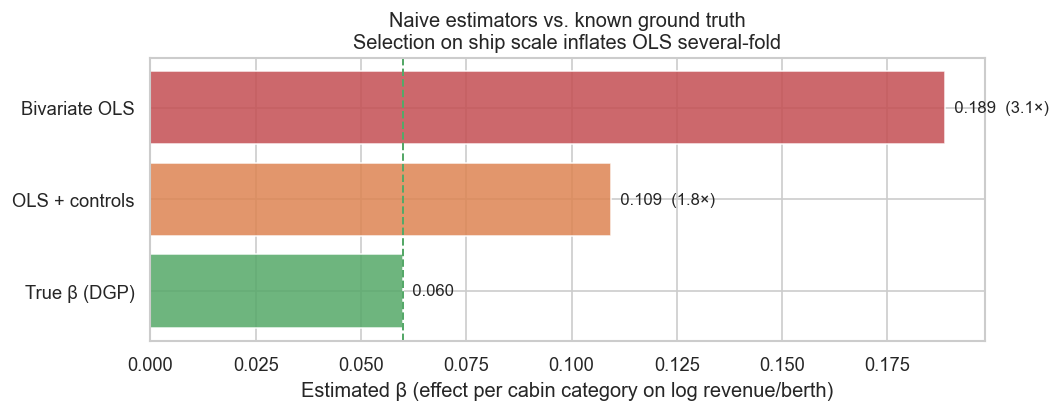

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.6))
rows = [
    ("Bivariate OLS",  m1.params["cabin_category_count"], "#C44E52"),
    ("OLS + controls", m2.params["cabin_category_count"], "#DD8452"),
    ("True β (DGP)",     0.06,                              "#55A868"),
]
y = np.arange(len(rows))[::-1]
for yi, (lab, val, col) in zip(y, rows):
    ax.barh(yi, val, color=col, alpha=0.85)
    ax.text(val, yi, f"  {val:.3f}  ({val/0.06:.1f}×)" if lab!="True β (DGP)" else f"  {val:.3f}",
            va="center", fontsize=10)
ax.axvline(0.06, color="#55A868", ls="--", lw=1.2)
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows])
ax.set_xlabel("Estimated β (effect per cabin category on log revenue/berth)")
ax.set_title("Naive estimators vs. known ground truth\nSelection on ship scale inflates OLS several-fold")
plt.tight_layout(); plt.savefig(OUT_DIR/"03_bias_ladder.png", bbox_inches="tight"); plt.show()

**Takeaway.** Even with brand tier, region and ship size as controls, OLS still sits well above 0.06 — observable proxies only partly capture the scale confounder. The backdoor path through unobserved ship scale stays open, which is what motivates the ship fixed-effects design in notebook 04.